Import Library

In [38]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


Load Dataset Breast Cancer

In [39]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Praktikum 12 | PCA/data/data (2).csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Cek Missing Value

In [40]:
df.isna().sum()


,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Hapus Kolom yang Tidak Dipakai

In [41]:
df = df.drop(columns=['Unnamed: 32'], errors='ignore')

Preprocessing Target

In [42]:
df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
print("Unique values in 'diagnosis' after stripping and uppercasing:", df['diagnosis'].unique())
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

Unique values in 'diagnosis' after stripping and uppercasing: ['M' 'B']


Pisahkan Fitur dan Label

In [43]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Standardisasi Data

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Baseline (Tanpa PCA)

In [46]:
svm_no_pca = SVC(kernel='rbf', gamma='scale')
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)
print("Akurasi tanpa PCA:", accuracy_score(y_test, y_pred_no_pca))

Akurasi tanpa PCA: 0.9824561403508771


Penerapan PCA

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


Explained Variance Ratio

In [48]:
pca.explained_variance_ratio_


array([0.42132688, 0.18887304, 0.09556973, 0.06284964, 0.05094745])

In [49]:
print("Total Variansi:", pca.explained_variance_ratio_.sum())


Total Variansi: 0.8195667453270539


Model SVM dengan PCA

In [50]:
svm_pca = SVC(kernel='rbf', gamma='scale')
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)
print("Akurasi dengan PCA:", accuracy_score(y_test, y_pred_pca))


Akurasi dengan PCA: 0.9736842105263158


Visualisasi 3D PCA

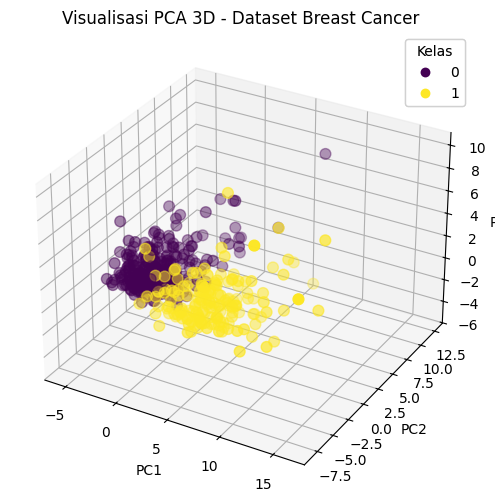

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Visualisasi 3D PCA (menggunakan data train)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0],   # PC1
    X_train_pca[:, 1],   # PC2
    X_train_pca[:, 2],   # PC3
    c=y_train,
    s=60
)

ax.set_title('Visualisasi PCA 3D - Dataset Breast Cancer')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Legend berdasarkan kelas (0 = Benign, 1 = Malignant)
legend = ax.legend(
    *scatter.legend_elements(),
    title="Kelas"
)
ax.add_artist(legend)

plt.show()
